In [1]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

In [2]:
iris = load_iris()

In [3]:
X = iris.data
y = iris.target

In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [6]:
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42,learning_rate=1.0)
ada_model.fit(X_train,Y_train)

,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [7]:
Y_pred = ada_model.predict(X_test)

In [8]:
accuracy = accuracy_score(Y_test,Y_pred)
accuracy

0.9333333333333333

In [9]:
gd_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,random_state=42)
gd_model.fit(X_train,Y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [10]:
Y_pred = gd_model.predict(X_test)
accuracy = accuracy_score(Y_test,Y_pred)
accuracy

1.0

In [11]:
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train,Y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [12]:
Y_pred = xgb_model.predict(X_test)

In [13]:
accuracy = accuracy_score(Y_test,Y_pred)
accuracy

1.0

In [14]:
comparison_df = pd.DataFrame({
    "Model": ["AdaBoost", "Gradient Boosting", "XGBoost"],
    "Accuracy": [
        accuracy_score(Y_test, ada_model.predict(X_test)),
        accuracy_score(Y_test, gd_model.predict(X_test)),
        accuracy_score(Y_test, xgb_model.predict(X_test))
    ]
})
comparison_df


,Model,Accuracy
0,AdaBoost,0.933333
1,Gradient Boosting,1.000000
2,XGBoost,1.000000


In [15]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

fixed_features = X_train[:, 2:].mean(axis=0)

grid = np.column_stack([
    xx.ravel(),
    yy.ravel(),
    np.tile(fixed_features, (xx.size, 1))
])

### AdaBoost plot

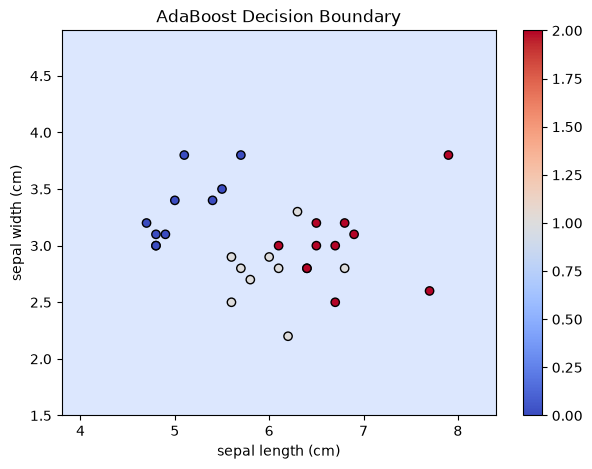

In [16]:
pred_ada = ada_model.predict(grid).reshape(xx.shape)
plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, pred_ada, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_test, cmap=plt.cm.coolwarm, edgecolor="black")
plt.title("AdaBoost Decision Boundary")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.colorbar()
plt.show()

### Gradient Boosting plot

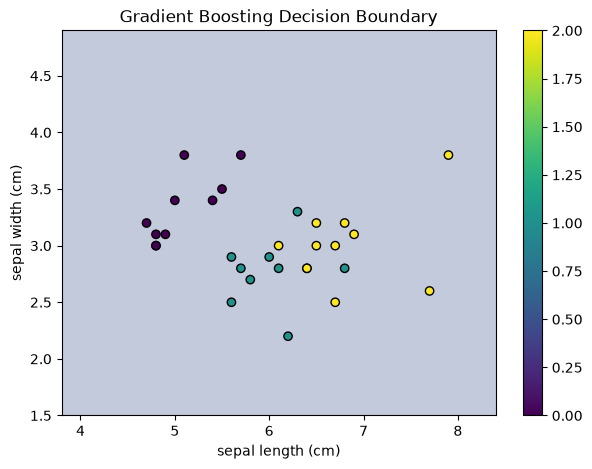

In [17]:
pred_gd = gd_model.predict(grid).reshape(xx.shape)
plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, pred_gd, alpha=0.3, cmap=plt.cm.viridis)
plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_test, cmap=plt.cm.viridis, edgecolor="black")
plt.title("Gradient Boosting Decision Boundary")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.colorbar()
plt.show()

### XGBoost plot

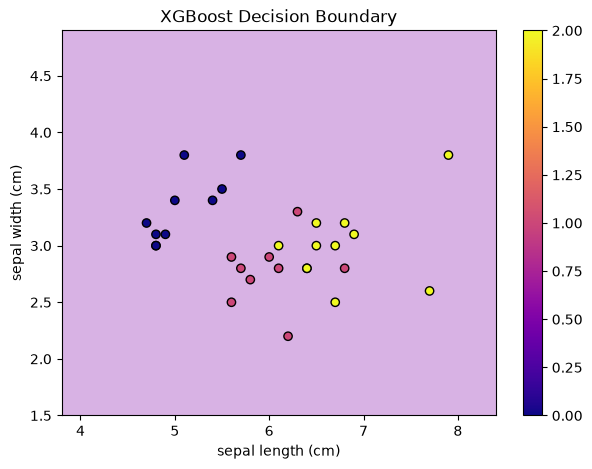

In [18]:
pred_xgb = xgb_model.predict(grid).reshape(xx.shape)
plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, pred_xgb, alpha=0.3, cmap=plt.cm.plasma)
plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_test, cmap=plt.cm.plasma, edgecolor="black")
plt.title("XGBoost Decision Boundary")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.colorbar()
plt.show()

## ConfusionMatrixDisplay

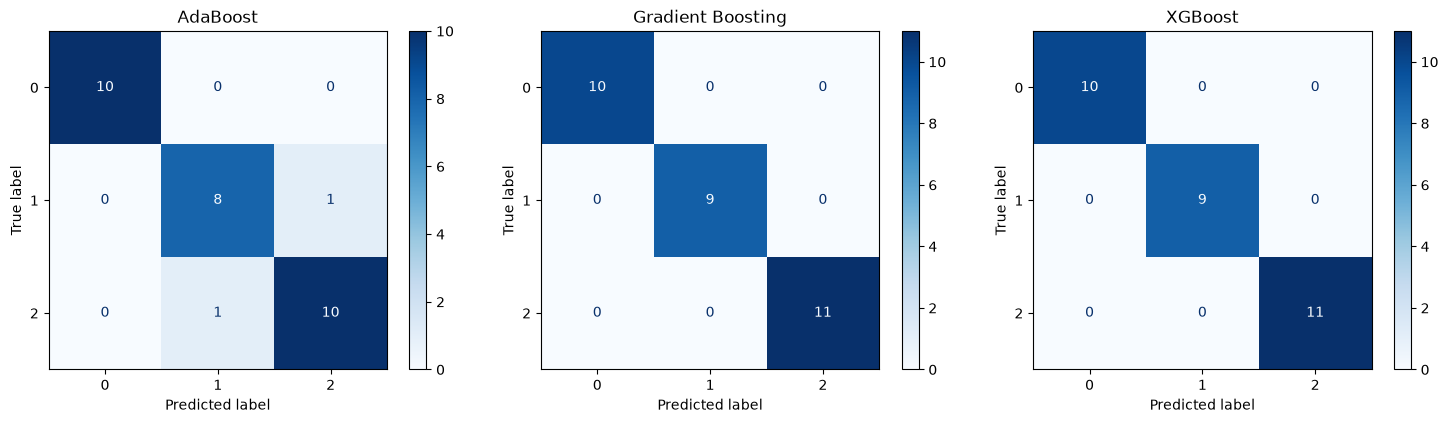

In [19]:
models = {
    "AdaBoost": ada_model,
    "Gradient Boosting": gd_model,
    "XGBoost": xgb_model
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for axis, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        Y_test,
        ax=axis,
        cmap="Blues"
    )
    axis.set_title(name)

plt.tight_layout()
plt.show()

## Side-by-Side Comparison

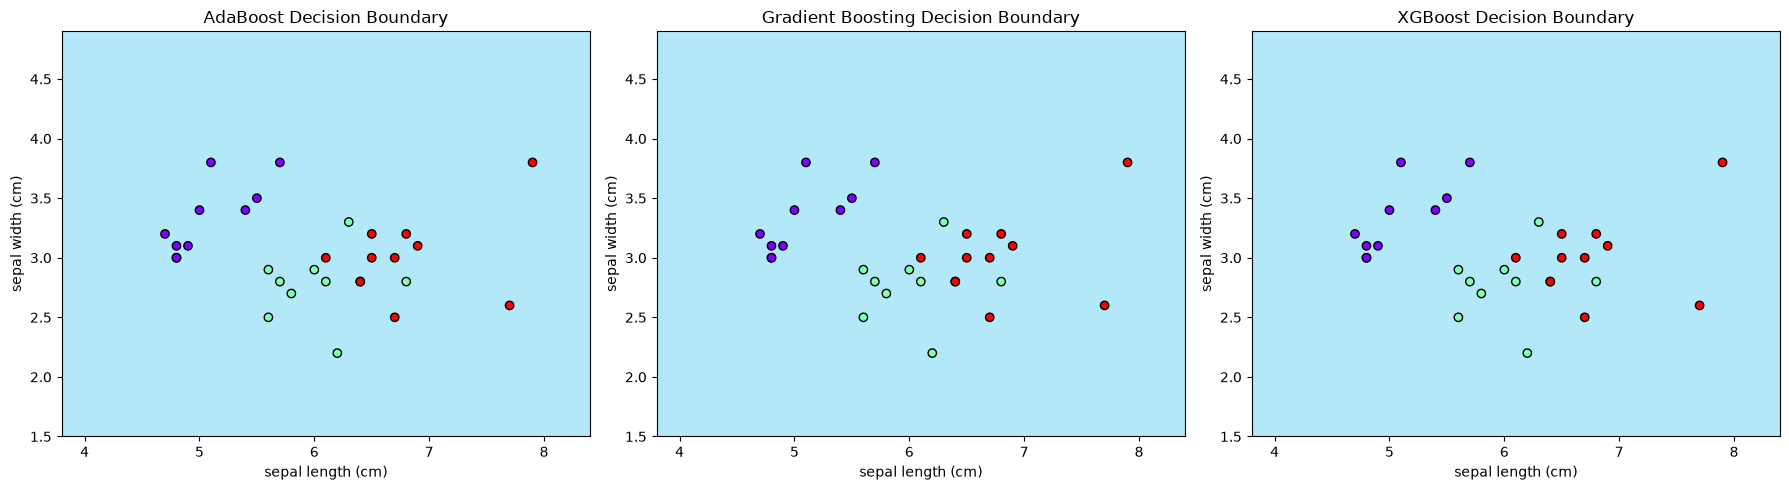

In [20]:
pred_ada = ada_model.predict(grid).reshape(xx.shape)
pred_gd  = gd_model.predict(grid).reshape(xx.shape)
pred_xgb = xgb_model.predict(grid).reshape(xx.shape)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = [
    ("AdaBoost", pred_ada, axes[0]),
    ("Gradient Boosting", pred_gd, axes[1]),
    ("XGBoost", pred_xgb, axes[2])
]
for name, pred, ax in models:
    ax.contourf(xx, yy, pred, alpha=0.3, cmap=plt.cm.rainbow)
    scatter = ax.scatter(X_test[:, 0], X_test[:, 1], c=Y_test, cmap=plt.cm.rainbow, edgecolor="black")
    ax.set_title(f"{name} Decision Boundary")
    ax.set_xlabel(iris.feature_names[0])
    ax.set_ylabel(iris.feature_names[1])
plt.tight_layout()
plt.show()